# 06: Brownian-driver to OU-response operator

**Status, 3 September:** complete. Acceptance, twelve primary MSE/$J_2$ fits and six uniform signature fits are recorded below. Detailed procedure: `../docs/neural_ode_operator_experiments.md` §4.

## Experiment

Experiment B learns a simultaneous stream transformation. Input is one Brownian driver over $[0,1]$; target is OU response driven by same increments over same interval. Model sees complete driver rather than a prefix, and produces complete response rather than forecast. Causal architecture prevents future driver values from changing earlier outputs.

Run order:

```bash
python scripts/run_ou_operator.py --config configs/neural_cde_brownian_ou.yaml --out results/runs/neural_cde_brownian_ou/acceptance --acceptance
python scripts/run_ou_operator_study.py --config configs/neural_cde_brownian_ou.yaml --out results/runs/neural_cde_brownian_ou --stage primary --evaluate-test
python scripts/run_ou_operator.py --config configs/neural_cde_brownian_ou.yaml --out results/runs/neural_cde_brownian_ou/signature_audit --signature-audit
python scripts/run_ou_operator_study.py --config configs/neural_cde_brownian_ou.yaml --out results/runs/neural_cde_brownian_ou --stage signature --evaluate-test
```

Primary stage starts only after acceptance file reports `passed: true`. Signature stage starts only after primary fits and scaling audit are reviewed.


## 1. Paired data

Let $M=256$, $T=1$, $\Delta t=T/M$ and $\tau_m=m\Delta t$. For path $i$, draw independent $\xi_m^{(i)}\sim\mathcal N(0,1)$ and set

$$
\Delta W_m^{(i)}=\sqrt{\Delta t}\,\xi_m^{(i)},\qquad W_0^{(i)}=0,\qquad W_{m+1}^{(i)}=W_m^{(i)}+\Delta W_m^{(i)}.
$$

With $\lambda=2$, $\sigma=0.5$ and $Y_0^{(i)}=0$, target recurrence is

$$
Y_{m+1}^{(i)}=Y_m^{(i)}-\lambda Y_m^{(i)}\Delta t+\sigma\Delta W_m^{(i)}.
$$

Same $\Delta W_m^{(i)}$ appears in driver and response, defining paired operator example $(W^{(i)},Y^{(i)})$. Fixed split seeds generate 512 training, 128 validation and 256 test pairs. Test paths remain unused until configuration and acceptance gates are fixed.


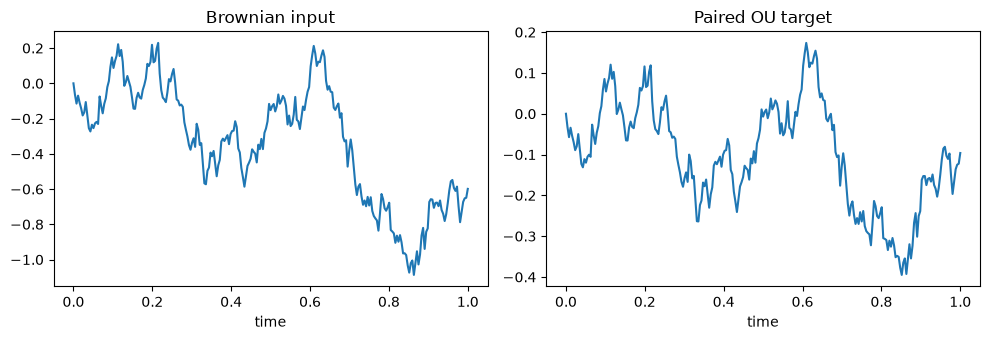

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from pathloss.datasets import brownian_ou_pairs

example = brownian_ou_pairs(1, n_steps=256, rng=12001)
figure, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(example['time'], example['driver'][0, :, 0])
axes[0].set_title('Brownian input')
axes[1].plot(example['time'], example['target'][0, :, 0])
axes[1].set_title('Paired OU target')
for axis in axes:
    axis.set_xlabel('time')
figure.tight_layout()


## 2. Target observations

Model receives all 257 driver values. Loss sees $C=64$ response values. Uniform condition uses $t_r=r/(C-1)$. Clustered condition uses

$$
t_r=1-\left(1-\frac{r}{C-1}\right)^3.
$$

Generated response is piecewise-linearly interpolated to these times. Prediction uses same interpolation rule. Driver paths, response paths, model initialization, batch order and optimizer remain shared across paired loss runs. Only target time condition and training discrepancy vary.


## 3. Path-output Neural CDE

Control is $X^{(i)}(t)=(t,W^{(i)}(t))$. Hidden state $h^{(i)}(t)\in\mathbb R^{16}$ starts from shared learned vector $\eta$ and follows

$$
dh^{(i)}(t)=V_{\theta,0}(h^{(i)}(t))\,dt+V_{\theta,1}(h^{(i)}(t))\,dW^{(i)}(t).
$$

$V_\theta:\mathbb R^{16}\to\mathbb R^{16\times2}$ is a two-layer tanh network of width 64. Affine decoder produces $\widehat Y^{(i)}(t)=q_\phi(h^{(i)}(t))$. Decoder acts throughout hidden trajectory. Earlier output therefore depends only on driver prefix.

This differs from final-summary query model in notebook 03. That model reads complete input into one vector before answering every time and cannot represent required causal stream transformation.


## 4. Discrete CDE solver

On control interval $[\tau_m,\tau_{m+1}]$, define increment $\Delta X_m^{(i)}=(\Delta t,\Delta W_m^{(i)})$. Reparameterize interval by $s\in[0,1]$. For hidden value $z$, increment field is

$$
F_m^{(i)}(z)=V_{\theta,0}(z)\Delta t+V_{\theta,1}(z)\Delta W_m^{(i)}.
$$

One RK4 step gives

$$
k_1=F_m^{(i)}(h_m),\quad k_2=F_m^{(i)}(h_m+k_1/2),\quad k_3=F_m^{(i)}(h_m+k_2/2),\quad k_4=F_m^{(i)}(h_m+k_3),
$$

$$
h_{m+1}=h_m+\frac{k_1+2k_2+2k_3+k_4}{6}.
$$

All operations are differentiable. A perturbation beginning after $\tau_m$ first changes $h_{m+1}$, leaving decoded prefix through $\tau_m$ unchanged.


## 5. Losses and training

For response residual $e_r^{(i)}=\widehat Y^{(i)}(t_r)-Y^{(i)}(t_r)$, primary losses are

$$
D_{\mathrm{MSE}}=\frac1C\sum_{r=0}^{C-1}|e_r^{(i)}|^2,\qquad D_{J_2}=\frac1T\sum_{r=0}^{C-1}w_r|e_r^{(i)}|^2,
$$

where $w_r$ are trapezoid elapsed-time weights. Batch loss averages path losses over batch. Three paired seeds use batch size 64, Adam learning rate $10^{-3}$ and 500 epochs: eight batches per epoch and 4,000 parameter updates. Deterministic epoch permutations are shared across losses. Fixed-budget final model is saved; validation does not select an epoch.

Optional signature losses use time-augmented response $(t,Y)$, initial-value anchor and training-target standard deviation as output scale. Global depth four and five local depth-two blocks each store 30 positive-level coordinates. Scaling audit precedes signature training.


## 6. Acceptance before comparison

Primary array runs only after one report confirms:

1. generated responses satisfy stated recurrence;
2. output shape is $(B,C,1)$ and finite gradient reaches every parameter;
3. driver perturbation changes future prediction;
4. perturbing driver after $\tau$ leaves prediction through $\tau$ unchanged within $10^{-7}$;
5. small-batch training loss falls below 10% of first-epoch value and below $10^{-3}$;
6. held-out MSE falls below 80% of untrained value;
7. split paths, target times, initialization and batch order reproduce under same seeds.

Thresholds are implementation gates fixed in configuration before acceptance run. Failure repairs implementation or increases training budget; thresholds remain fixed.


## 7. Evaluation

Every final model is decoded at all 257 fine-grid times. Report fine-grid MSE, $J_1$, $J_2$, $J_4$, $L^\infty$, global and local signature discrepancies, runtime and peak memory. Signature discrepancies are also calculated on the 64-point training polygon. This separates optimization of the specified training objective from agreement on the finer path. Independent dynamics residual is

$$
R_m^{(i)}=\widehat Y_{m+1}^{(i)}-\widehat Y_m^{(i)}+\lambda\widehat Y_m^{(i)}\Delta t-\sigma\Delta W_m^{(i)},
$$

with score $E_{\mathrm{dyn}}=(n_{\mathrm{test}}M)^{-1}\sum_{i,m}|R_m^{(i)}|^2$. No training loss directly optimizes this score.

For condition $q$ and seed $s$, define paired effect

$$
\delta_{q,s}=E_{q,s}^{J_2\text{-trained}}-E_{q,s}^{\mathrm{MSE\text{-trained}}},\qquad \Delta_s=\delta_{\mathrm{clustered},s}-\delta_{\mathrm{uniform},s}.
$$

Elapsed-time mechanism predicts $\Delta_s<0$. Near-zero error for all fits means OU served its intended exact-learnability calibration role.


In [2]:
import json
import pandas as pd
from IPython.display import Markdown, display

RESULT_ROOT = REPO_ROOT / 'results/runs/neural_cde_brownian_ou'
rows = []
for path in RESULT_ROOT.glob('seed*/*/*/meta.json'):
    meta = json.loads(path.read_text())
    metrics = meta.get('test') or meta.get('validation')
    if metrics:
        rows.append({
            'seed': meta['fit_config']['seed'],
            'condition': meta['fit_config']['condition'],
            'loss': meta['fit_config']['loss'],
            'initial_fingerprint': meta['initial_fingerprint'],
            'data_fingerprint': meta['data_fingerprint'],
            'target_time_fingerprint': meta['target_time_fingerprint'],
            'order_fingerprint': meta['order_fingerprint'],
            **metrics,
        })
results = pd.DataFrame(rows)
display(results if not results.empty else Markdown('Comparative results are absent.'))


,seed,condition,loss,initial_fingerprint,data_fingerprint,target_time_fingerprint,order_fingerprint,target_mse,target_j2,fine_mse,fine_j1,fine_j2,fine_j4,fine_linf,sig_global,sig_local,dynamics_residual,target_sig_global,target_sig_local
0,2,uniform,mse,73313b39d896f3f5a23733396ad61fe97ca6db685d00c5...,17ec180478738da20243eb55394260e707b69ea20194d8...,fcf4cec095a7c49f6c058824e1a9bbe2fd82653913065a...,8343fd56434ba35ff6b3f007caaf736784b6d0d323b55c...,2.241694e-07,2.205879e-07,2.233010e-07,0.000310,2.224162e-07,1.029496e-12,0.001182,0.000122,0.000008,1.263941e-08,NaN,NaN
1,2,uniform,sig_local,73313b39d896f3f5a23733396ad61fe97ca6db685d00c5...,17ec180478738da20243eb55394260e707b69ea20194d8...,fcf4cec095a7c49f6c058824e1a9bbe2fd82653913065a...,8343fd56434ba35ff6b3f007caaf736784b6d0d323b55c...,2.567152e-07,2.551054e-07,2.558282e-07,0.000398,2.554286e-07,4.261357e-13,0.000969,0.000035,0.000002,2.774037e-09,0.000035,0.000002
2,2,uniform,sig_global,73313b39d896f3f5a23733396ad61fe97ca6db685d00c5...,17ec180478738da20243eb55394260e707b69ea20194d8...,fcf4cec095a7c49f6c058824e1a9bbe2fd82653913065a...,8343fd56434ba35ff6b3f007caaf736784b6d0d323b55c...,7.668916e-07,7.705042e-07,7.728841e-07,0.000609,7.737965e-07,4.796010e-12,0.002094,0.000166,0.000015,2.181602e-08,0.000166,0.000014
3,2,uniform,j2,73313b39d896f3f5a23733396ad61fe97ca6db685d00c5...,17ec180478738da20243eb55394260e707b69ea20194d8...,fcf4cec095a7c49f6c058824e1a9bbe2fd82653913065a...,8343fd56434ba35ff6b3f007caaf736784b6d0d323b55c...,2.274850e-07,2.239448e-07,2.266541e-07,0.000313,2.257797e-07,1.021775e-12,0.001171,0.000120,0.000008,1.250008e-08,NaN,NaN
4,2,clustered,mse,73313b39d896f3f5a23733396ad61fe97ca6db685d00c5...,17ec180478738da20243eb55394260e707b69ea20194d8...,48e661930a53669a7fa3b5367d4134d6a45853e5a34a8d...,8343fd56434ba35ff6b3f007caaf736784b6d0d323b55c...,1.021753e-06,6.244741e-07,6.281762e-07,0.000639,6.273983e-07,1.842023e-12,0.001710,0.000197,0.000012,1.956577e-08,NaN,NaN
5,2,clustered,j2,73313b39d896f3f5a23733396ad61fe97ca6db685d00c5...,17ec180478738da20243eb55394260e707b69ea20194d8...,48e661930a53669a7fa3b5367d4134d6a45853e5a34a8d...,8343fd56434ba35ff6b3f007caaf736784b6d0d323b55c...,4.938570e-07,2.292747e-07,2.309672e-07,0.000323,2.300574e-07,9.504926e-13,0.001213,0.000125,0.000008,1.250915e-08,NaN,NaN
6,0,uniform,mse,241a13ba5568f079ea3ba8096254cacb52339dc24162a1...,17ec180478738da20243eb55394260e707b69ea20194d8...,fcf4cec095a7c49f6c058824e1a9bbe2fd82653913065a...,8371c0526c9bc64763b7b9f04ea8e30753cfaa338bbb8c...,3.774257e-07,3.740010e-07,3.763619e-07,0.000414,3.755150e-07,2.204556e-12,0.001662,0.000151,0.000011,1.547470e-08,NaN,NaN
7,0,uniform,sig_local,241a13ba5568f079ea3ba8096254cacb52339dc24162a1...,17ec180478738da20243eb55394260e707b69ea20194d8...,fcf4cec095a7c49f6c058824e1a9bbe2fd82653913065a...,8371c0526c9bc64763b7b9f04ea8e30753cfaa338bbb8c...,2.300930e-06,2.302131e-06,2.319762e-06,0.001177,2.320131e-06,2.261864e-11,0.003387,0.000293,0.000065,8.001038e-08,0.000291,0.000062
8,0,uniform,sig_global,241a13ba5568f079ea3ba8096254cacb52339dc24162a1...,17ec180478738da20243eb55394260e707b69ea20194d8...,fcf4cec095a7c49f6c058824e1a9bbe2fd82653913065a...,8371c0526c9bc64763b7b9f04ea8e30753cfaa338bbb8c...,3.745220e-06,3.735241e-06,3.753888e-06,0.001319,3.751466e-06,2.214463e-10,0.003320,0.001051,0.000051,5.901556e-08,0.001049,0.000048
9,0,uniform,j2,241a13ba5568f079ea3ba8096254cacb52339dc24162a1...,17ec180478738da20243eb55394260e707b69ea20194d8...,fcf4cec095a7c49f6c058824e1a9bbe2fd82653913065a...,8371c0526c9bc64763b7b9f04ea8e30753cfaa338bbb8c...,3.914091e-07,3.878412e-07,3.902780e-07,0.000419,3.893955e-07,2.222361e-12,0.001717,0.000166,0.000011,1.587060e-08,NaN,NaN


In [3]:
if not results.empty and {'mse', 'j2'} <= set(results['loss']):
    primary = results[results['loss'].isin(['mse', 'j2'])]
    paired = primary.pivot(index=['seed', 'condition'], columns='loss', values='fine_j2')
    paired['delta'] = paired['j2'] - paired['mse']
    contrast = paired['delta'].unstack('condition')
    contrast['Delta'] = contrast['clustered'] - contrast['uniform']
    display(paired)
    display(contrast)
    primary_means = primary.groupby(['condition', 'loss'])['fine_j2'].mean().unstack('loss')
    primary_means['j2_to_mse_ratio'] = primary_means['j2'] / primary_means['mse']
    primary_means['relative_reduction'] = 1.0 - primary_means['j2_to_mse_ratio']
    display(primary_means)


loss                      j2           mse         delta
seed condition                                          
0    clustered  4.195430e-07  1.155934e-06 -7.363910e-07
     uniform    3.893955e-07  3.755150e-07  1.388054e-08
1    clustered  4.527850e-07  4.976885e-07 -4.490349e-08
     uniform    4.849526e-07  5.037665e-07 -1.881392e-08
2    clustered  2.300574e-07  6.273983e-07 -3.973409e-07
     uniform    2.257797e-07  2.224162e-07  3.363454e-09

condition,clustered,uniform,Delta
seed,,,
0,-7.363910e-07,1.388054e-08,-7.502715e-07
1,-4.490349e-08,-1.881392e-08,-2.608957e-08
2,-3.973409e-07,3.363454e-09,-4.007043e-07


loss,j2,mse,j2_to_mse_ratio,relative_reduction
condition,,,,
clustered,3.674618e-07,7.603402e-07,0.483286,0.516714
uniform,3.667092e-07,3.672326e-07,0.998575,0.001425


## 8. Primary result

All twelve primary fits are complete. Uniform observations give no systematic MSE versus $J_2$ difference: across-seed mean fine-grid $J_2$ is $3.67\times10^{-7}$ under both training losses, and the lower error splits across seeds. Under clustered observations, $J_2$ training gives lower fine-grid $J_2$ in all three paired seeds. Ratio of across-seed means is $0.483$, corresponding to a $51.7\%$ reduction relative to MSE training. Predefined sampling contrast $\Delta_s$ is negative for all three seeds.

Clustered $J_2$ training also lowers mean dynamics residual and both dense signature discrepancies. Uniform values remain essentially tied. This transfers the sampling-measure mechanism from fitting one path to learning a causal map across Brownian drivers and held-out OU responses.

Every fit has small absolute error relative to training-target standard deviation $0.213$. Late validation histories fluctuate near this low-error floor; best validation checkpoint does not favour $J_2$ in every clustered seed. Result therefore concerns equal 500-epoch training budgets rather than different attainable optima. OU has served its intended exact-learnability calibration role.

Signature audit reports finite nonzero component values and parameter gradients at every retained level. Training-target standard-deviation scaling is frozen. Higher-level gradients are smaller than anchor and level-one gradients, so acceptance authorizes comparative runs without asserting balanced or easy optimization.


In [4]:
uniform = results[results['condition'].eq('uniform')].copy()
fingerprint_columns = [
    'initial_fingerprint', 'data_fingerprint',
    'target_time_fingerprint', 'order_fingerprint',
]
pairing = uniform.groupby('seed')[fingerprint_columns].nunique()
display(pairing)
assert (pairing == 1).all().all()


,initial_fingerprint,data_fingerprint,target_time_fingerprint,order_fingerprint
seed,,,,
0,1,1,1,1
1,1,1,1,1
2,1,1,1,1


## 9. Signature comparison

Signature runs store their 64-point held-out polygon discrepancies directly. Primary runs predate those two fields, so the next cell reloads every saved final model and deterministically reevaluates training and test splits. No fitting or model selection occurs. Training rows diagnose optimization of the fitted objective. Test rows give a like-for-like held-out comparison, while fine-grid columns test whether ordering persists on all 257 response values.


In [5]:
import torch
from pathloss.fixed_path import observation_times
from pathloss.operator import (
    OUOperatorTrainConfig, evaluate_ou_operator, make_ou_operator_model,
    make_ou_operator_splits,
)

reevaluated = []
for seed in range(3):
    for loss in ('mse', 'j2', 'sig_global', 'sig_local'):
        run = RESULT_ROOT / f'seed{seed}' / 'uniform' / loss
        meta = json.loads((run / 'meta.json').read_text())
        cfg = OUOperatorTrainConfig(**meta['fit_config'])
        model = make_ou_operator_model(cfg)
        state = torch.load(run / 'model.pt', map_location=cfg.device, weights_only=True)
        model.load_state_dict(state)
        splits = make_ou_operator_splits(cfg)
        target_time = observation_times(cfg.n_target, cfg.condition, device=cfg.device)
        for split_name in ('train', 'test'):
            metrics, _ = evaluate_ou_operator(
                model, splits[split_name], target_time,
                lambd=cfg.lambd, sigma=cfg.sigma,
                signature_output_scale=meta['signature_output_scale'],
                signature_global_depth=cfg.signature_global_depth,
                signature_local_depth=cfg.signature_local_depth,
                signature_local_intervals=cfg.signature_local_intervals,
            )
            reevaluated.append({
                'seed': seed, 'loss': loss, 'split': split_name, **metrics,
            })
recomputed_metrics = pd.DataFrame(reevaluated)
primary_signature_metrics = recomputed_metrics[
    recomputed_metrics['split'].eq('test')
    & recomputed_metrics['loss'].isin(['mse', 'j2'])
]
display(primary_signature_metrics[[
    'seed', 'loss', 'target_sig_global', 'sig_global',
    'target_sig_local', 'sig_local',
]])
display(recomputed_metrics[recomputed_metrics['split'].eq('train')][[
    'seed', 'loss', 'target_sig_global', 'target_sig_local', 'target_mse',
]])


,seed,loss,target_sig_global,sig_global,target_sig_local,sig_local
1,0,mse,0.000151,0.000151,0.000010,0.000011
3,0,j2,0.000166,0.000166,0.000011,0.000011
9,1,mse,0.000257,0.000258,0.000017,0.000017
11,1,j2,0.000251,0.000252,0.000017,0.000017
17,2,mse,0.000122,0.000122,0.000007,0.000008
19,2,j2,0.000119,0.000120,0.000007,0.000008


,seed,loss,target_sig_global,target_sig_local,target_mse
0,0,mse,0.000059,0.000010,3.555844e-07
2,0,j2,0.000064,0.000011,3.657431e-07
4,0,sig_global,0.000609,0.000048,3.250880e-06
6,0,sig_local,0.000296,0.000068,2.157781e-06
8,1,mse,0.000106,0.000017,5.151774e-07
10,1,j2,0.000107,0.000017,4.967910e-07
12,1,sig_global,0.001932,0.000286,1.597909e-05
14,1,sig_local,0.000079,0.000008,5.906091e-07
16,2,mse,0.000047,0.000007,2.255215e-07
18,2,j2,0.000048,0.000007,2.295920e-07


In [6]:
signature_rows = uniform[uniform['loss'].isin(['sig_global', 'sig_local'])]
comparison_rows = []
for seed in range(3):
    pointwise = primary_signature_metrics[primary_signature_metrics['seed'].eq(seed)]
    for loss, target_metric, fine_metric in [
        ('sig_global', 'target_sig_global', 'sig_global'),
        ('sig_local', 'target_sig_local', 'sig_local'),
    ]:
        fitted = signature_rows[
            signature_rows['seed'].eq(seed) & signature_rows['loss'].eq(loss)
        ].iloc[0]
        comparison_rows.append({
            'seed': seed,
            'loss': loss,
            'observed_grid_signature_ratio': fitted[target_metric] / pointwise[target_metric].min(),
            'fine_signature_ratio': fitted[fine_metric] / pointwise[fine_metric].min(),
            'fine_mse_ratio': fitted['fine_mse'] / pointwise['fine_mse'].min(),
            'linf_ratio': fitted['fine_linf'] / pointwise['fine_linf'].min(),
            'dynamics_ratio': fitted['dynamics_residual'] / pointwise['dynamics_residual'].min(),
        })
signature_comparison = pd.DataFrame(comparison_rows)
display(signature_comparison)


,seed,loss,observed_grid_signature_ratio,fine_signature_ratio,fine_mse_ratio,linf_ratio,dynamics_ratio
0,0,sig_global,6.953443,6.950206,9.974171,1.998045,3.813684
1,0,sig_local,5.963670,5.979643,6.163663,2.038467,5.170405
2,1,sig_global,16.614866,16.607642,35.828721,3.718868,11.400166
3,1,sig_local,0.444000,0.434577,1.330102,0.700583,0.272216
4,2,sig_global,1.387896,1.391741,3.461172,1.788816,1.745267
5,2,sig_local,0.299488,0.291532,1.145664,0.828056,0.221921


In [7]:
history_rows = []
for run in sorted(RESULT_ROOT.glob('seed*/uniform/sig_*/history.json')):
    history = json.loads(run.read_text())
    values = [row['train_loss'] for row in history]
    best_epoch = min(range(len(values)), key=values.__getitem__)
    history_rows.append({
        'seed': int(run.parts[-4].removeprefix('seed')),
        'loss': run.parts[-2],
        'best_epoch': best_epoch,
        'best_training_loss': values[best_epoch],
        'final_training_loss': values[-1],
        'final_to_best_ratio': values[-1] / values[best_epoch],
    })
history_stability = pd.DataFrame(history_rows)
display(history_stability)


,seed,loss,best_epoch,best_training_loss,final_training_loss,final_to_best_ratio
0,0,sig_global,328,0.000037,0.001050,28.370640
1,0,sig_local,440,0.000002,0.000202,100.053439
2,1,sig_global,348,0.000052,0.001495,28.541861
3,1,sig_local,457,0.000003,0.000007,2.643746
4,2,sig_global,424,0.000022,0.000051,2.319949
5,2,sig_local,482,0.000002,0.000002,1.306953


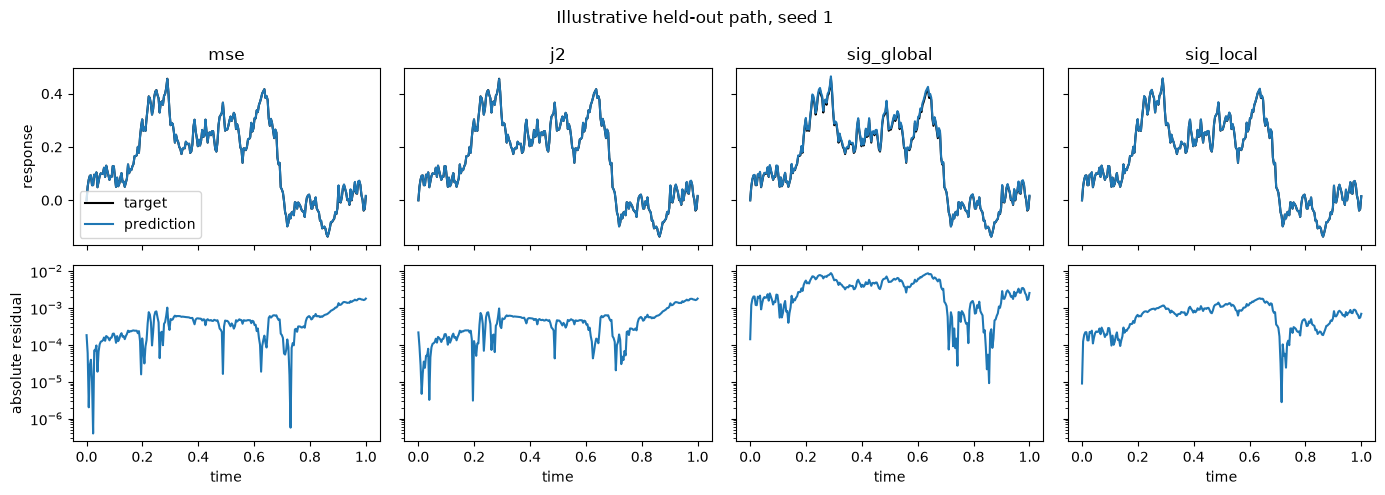

In [8]:
import numpy as np

illustrative_seed = 1
losses = ('mse', 'j2', 'sig_global', 'sig_local')
figure, axes = plt.subplots(2, len(losses), figsize=(14, 5), sharex=True, sharey='row')
for column, loss in enumerate(losses):
    stored = np.load(
        RESULT_ROOT / f'seed{illustrative_seed}' / 'uniform' / loss / 'test_paths.npz'
    )
    time = stored['time']
    target = stored['target'][0, :, 0]
    prediction = stored['prediction'][0, :, 0]
    axes[0, column].plot(time, target, color='black', label='target')
    axes[0, column].plot(time, prediction, label='prediction')
    axes[0, column].set_title(loss)
    axes[1, column].plot(time, np.abs(prediction - target))
    axes[1, column].set_yscale('log')
    axes[1, column].set_xlabel('time')
axes[0, 0].set_ylabel('response')
axes[1, 0].set_ylabel('absolute residual')
axes[0, 0].legend()
figure.suptitle('Illustrative held-out path, seed 1')
figure.tight_layout()


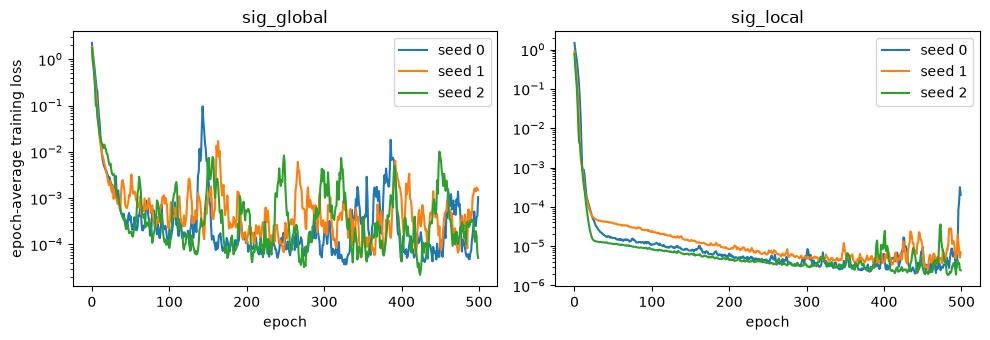

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
for axis, loss in zip(axes, ('sig_global', 'sig_local')):
    for seed in range(3):
        history_path = RESULT_ROOT / f'seed{seed}' / 'uniform' / loss / 'history.json'
        history = json.loads(history_path.read_text())
        axis.plot([row['epoch'] for row in history], [row['train_loss'] for row in history], label=f'seed {seed}')
    axis.set_yscale('log')
    axis.set_title(loss)
    axis.set_xlabel('epoch')
    axis.legend()
axes[0].set_ylabel('epoch-average training loss')
figure.tight_layout()


### 9.1 Result

All six signature fits share initialization, data, target times, batch order and output scaling with paired uniform MSE and $J_2$ fits. Coarse and fine signature ratios agree closely, so 64-point response representation does not explain observed rankings on this OU task.

Global-signature training has higher global discrepancy than the best paired pointwise fit in all three seeds: dense ratios are 6.95, 16.61 and 1.39. Its final training-set objective is also higher in all three pairs. Training histories reach much smaller values earlier and then rise; final-to-best training-loss ratios are 28.4, 28.5 and 2.32. Final global results therefore show unstable optimization under fixed Adam schedule rather than a path selected by global-signature geometry.

Local-signature training has lower local discrepancy than both pointwise fits in seeds one and two, on training data and held-out paths. Dense local-signature ratios are 0.435 and 0.292, while dense MSE ratios are 1.33 and 1.15. These two fits trade a modest increase in average squared error for a different notion of path agreement. They also lower maximum error by 30% and 17%, and lower OU dynamics residual by 73% and 78%, although neither quantity appears in training loss. Seed zero is unstable: final local training loss is about one hundred times its minimum and every main test metric is worse.

Local result supplies two consistent paired examples of signature geometry carrying into operator learning, with one optimization failure. Three seeds do not support a robust superiority claim. Global result supplies an optimization warning. OU remains a linear, accurately learnable calibration; stronger conclusions about path behaviour require a nonlinear stream transformation with outcomes such as crossing time or occupation.

## 10. Conclusion

Experiment B is complete. Neural CDE learns a causal Brownian-driver to OU-response operator with small held-out error. Clustered-target comparison transfers elapsed-time weighting result from Experiment A to path-to-path learning. Signature comparison shows that local structural closeness can select an operator with different pointwise and dynamical trade-offs, while pure signature objectives require more stable optimization. Further OU repetitions have lower value than moving to a nonlinear operator and treating optimizer design as an explicit experimental factor.
